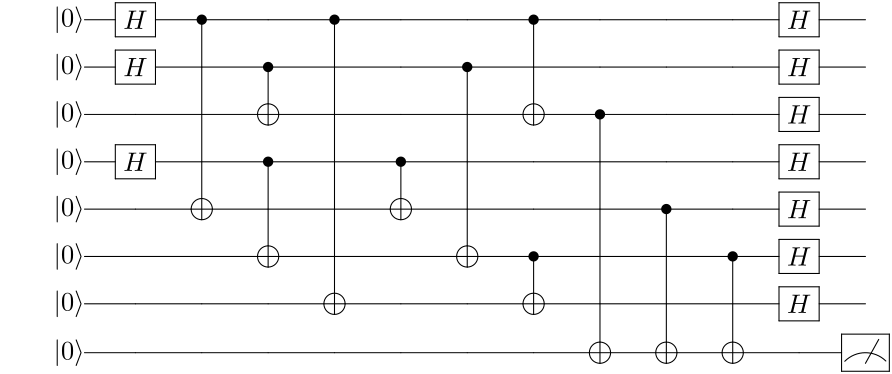

In [25]:
import qsample as qs
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import tqdm as _tqdm
_tqdm.tqdm = tqdm
flag_ft_plus_S = qs.Circuit(ticks=[
    {"init": {0, 1, 2, 3, 4, 5, 6, 7}},

    # state prep: |+> on 0,1,3
    {"H": {0, 1, 3}},

    # CNOT columns (left -> right, from the figure)
    {"CNOT": {(0, 4)}},
    {"CNOT": {(1, 2), (3, 5)}},
    {"CNOT": {(0, 6)}},
    {"CNOT": {(3, 4)}},
    {"CNOT": {(1, 5)}},
    {"CNOT": {(5, 6), (0, 2)}},
    {"CNOT": {(2, 7)}},
    {"CNOT": {(4, 7)}},
    {"CNOT": {(5, 7)}},

    # final single-qubit gates (right side)
    {"H": {0, 1, 2, 3, 4, 5, 6}},
    {"measure": {7}},
])

# 可视化（如果你装了 graphviz 等依赖）
flag_ft_plus_S.draw()

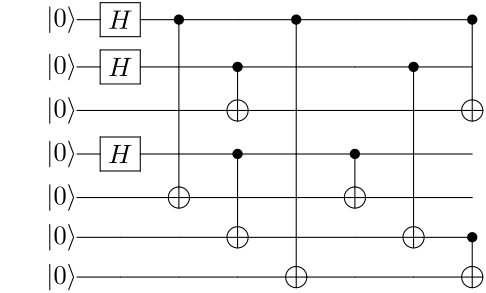

In [14]:
import qsample as qs
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 定义 Steane Code [[7,1,3]] |0>_L 制备电路
# ==========================================
def get_stean_zero_prep():
    """
    基于论文 Fig 11 的 Steane Code |0>_L 制备电路 (Non-FT part for simplicity or FT if flagged).
    这里我们实现标准的编码电路。
    """
    # 7个物理比特
    qubits = {0, 1, 2, 3, 4, 5, 6}
    
    ticks = [
        {"init": qubits},
        # Hadamard on 0, 1, 3
        {"H": {0, 1, 3}},
        # CNOT 序列 (标准 Steane 编码)
         {"CNOT": {(0, 4)}},
         {"CNOT": {(1, 2), (3, 5)}},
         {"CNOT": {(0, 6)}},
         {"CNOT": {(3, 4)}},
         {"CNOT": {(1, 5)}},
         {"CNOT": {(5, 6), (0, 2)}},
        # 如果是制备 |+>，末尾需要加 Transversal H；如果是 |0>，则不需要
    ]
    return qs.Circuit(ticks=ticks)
c=get_stean_zero_prep()
c.draw()





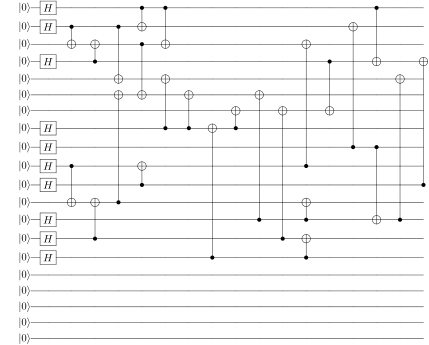

In [15]:
def get_tetra_zero_prep():
    """
    基于论文 Figure 12 复现 Tetrahedral Code [[15,1,3]] |0>_L 制备电路。
    包含初始化、H门层和特定的 CNOT 序列。
    """
    # 15个物理比特
    qubits = set(range(15))
    qubits_all = set(range(20))
    ticks = [
        # 1. 初始化所有比特为 |0>
        {"init": qubits_all},
        
        # 2. H 门层
        # 根据 Figure 12 左侧的 label，以下比特初始状态为 |+> (即对 |0> 作用 H)
        # 观察图示：0, 1, 3, 7, 8, 9, 10, 12, 13, 14
        {"H": {0, 1, 3, 7, 8, 9, 10, 12, 13, 14}}, 
        
        # 3. CNOT 序列 (根据图中颜色编号顺序转录)
        # 注意：图中实心点(Dot)是控制位，空心圈(Circle)是目标位
        
        
        {"CNOT": {(1, 2), (9, 11)}},   
        {"CNOT": {(3, 2), (13, 11)}},  
        {"CNOT": {(1, 4), (11, 5)}},
        {"CNOT": {(0, 1), (2, 5), (10, 9)}},
        {"CNOT": {(0, 2), (7, 4)}},  
        {"CNOT": {(7, 5)}},
        {"CNOT": {(14, 7)}},
        {"CNOT": {(7, 6)}},
        {"CNOT": {(12, 5)}},
        {"CNOT": {(13, 6)}},
        {"CNOT": {(9, 2), (12, 11), (14, 13)}},
        {"CNOT": {(3, 6)}},
        {"CNOT": {(8, 1)}},
        {"CNOT": {(0, 3), (8, 12)}},           
        {"CNOT": {(12, 4)}},           
        {"CNOT": {(10, 3)}}, 

    ]
     
    return qs.Circuit(ticks=ticks)
c1=get_tetra_zero_prep()
c1.draw(scale=0.8)

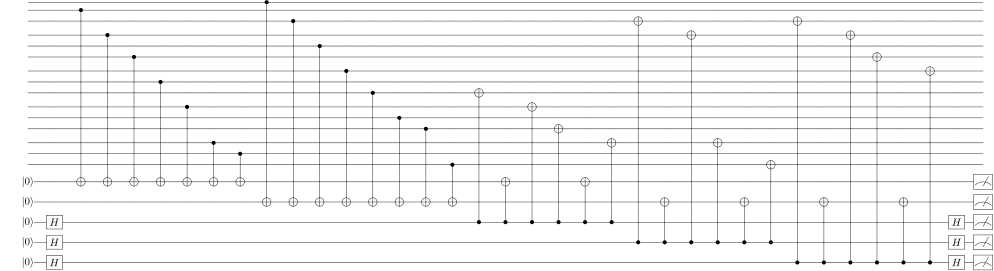

In [16]:
def get_tetra_flag_verification():
    ancillas = (15, 16, 17, 18, 19)

    # ========= 按你图中的顺序（编号顺序） =========
    # Red:  控制在数据比特上，目标是 ancilla 15（|0>）
    red_controls = [1, 3, 5, 7, 9, 12, 13]          # 图中红色 1..7
    # Blue: 控制在数据比特上，目标是 ancilla 16（|0>）
    blue_controls = [0, 2, 4, 6, 8, 10, 11, 14]     # 图中蓝色 1..8

    # Green: ancilla 17（|+>）作为控制，目标是数据比特 8..13（图中绿 8..13）
    green_targets = [8, 15, 9, 11, 15, 12]

    # Orange: ancilla 18（|+>）作为控制，目标按图中橙 14..19 的顺序
    # （从你图能看出来：两根很长的到上方 qubit，再加四根较短的到中下方）
    orange_targets = [2, 16, 3, 12, 16, 14]

    # Magenta: ancilla 19（|+>）作为控制，目标按图中粉 9..14 的顺序
    # （你图里：四根长的到最上方区域 + 两根短的到靠近底部的线）
    magenta_targets = [2, 16, 3, 5, 16, 6]

    ticks = []

    # 1) 初始化 ancilla
    ticks.append({"init": ancillas})
    # 2) 17/18/19 准备到 |+>
    ticks.append({"H": {17, 18, 19}})

    # 3) 红：data -> 15（严格串行）
    for c in red_controls:
        ticks.append({"CNOT": {(c, 15)}})

    # 4) 蓝：data -> 16（严格串行）
    for c in blue_controls:
        ticks.append({"CNOT": {(c, 16)}})

    # 5) 绿：17 -> data（严格串行）
    for t in green_targets:
        ticks.append({"CNOT": {(17, t)}})

    # 6) 橙：18 -> data（严格串行）
    for t in orange_targets:
        ticks.append({"CNOT": {(18, t)}})

    # 7) 粉：19 -> data（严格串行）
    for t in magenta_targets:
        ticks.append({"CNOT": {(19, t)}})

    # 8) X-check ancilla 切回 Z 基测量
    ticks.append({"H": {17, 18, 19}})
    # 9) 测量所有 ancilla
    ticks.append({"measure": ancillas})

    return qs.Circuit(ticks=ticks)

c = get_tetra_flag_verification()
c.draw(scale=0.8)







In [17]:
def measure_Z_string(data_qubits, anc):
    ticks = []
    ticks.append({"init": {anc}}) # anc=|0>
    for q in data_qubits:
        ticks.append({"CNOT": {(q, anc)}}) # data -> anc
    ticks.append({"measure": {anc}})
    return qs.Circuit(ticks=ticks, noisy=False) # 这类“理想测量”一般设 noisy=False

def measure_X_string(data_qubits, anc):
    ticks = []
    ticks.append({"init": {anc}})
    ticks.append({"H": {anc}}) # anc=|+>
    for q in data_qubits:
        ticks.append({"CNOT": {(anc, q)}}) # anc -> data
    ticks.append({"H": {anc}})
    ticks.append({"measure": {anc}})
    return qs.Circuit(ticks=ticks, noisy=False)

KX = [
    [0,3,6,7],
    [3,6,10,13],
    [6,7,13,14],
    [8,9,11,12],
    [1,2,4,5],
    [4,5,6,7],
    [2,3,5,6],
    [4,5,11,12],
    [2,5,9,11],
    [5,6,11,13],
]


KZ = [
    [0,1,2,3,4,5,6,7],
    [2,3,5,6,9,10,11,13],
    [4,5,6,7,11,12,13,14],
    [1,2,4,5,8,9,11,12],
]


ZL = [0,1,4,7,8,12,14] 

def verify_noiseless(prep_circuit):
    st = qs.StabilizerSimulator(20)  # 给够qubit数，后面会用到 ancilla
    st.run(prep_circuit)

    anc = 15
    # 测所有 KZ：期望都是 +1 => measurement bit=0（偶校验）
    for i, supp in enumerate(KZ, 1):
        m = st.run(measure_Z_string(supp, anc))
        assert m == "0", f"KZ_{i} failed, got {m}"

    # 测所有 KX：期望都是 +1
    for i, supp in enumerate(KX, 1):
        m = st.run(measure_X_string(supp, anc))
        assert m == "0", f"KX_{i} failed, got {m}"

    # 测 logical Z：|0>_L 期望 +1
    m = st.run(measure_Z_string(ZL, anc))
    assert m == "0", f"Logical Z failed, got {m}"

    return True

verify_noiseless(get_tetra_zero_prep())
print("Noiseless verification passed.")


Noiseless verification passed.


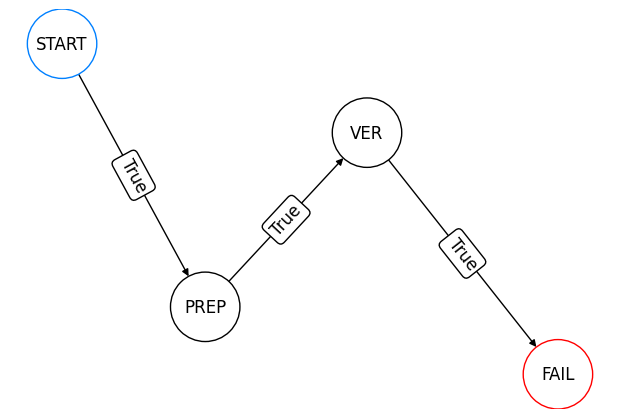

In [18]:
def accept_all(msmt_int: int) -> bool:
    return msmt_int == 0

def build_tetra_protocol_accept():
    prep = get_tetra_zero_prep()
    ver  = get_tetra_flag_verification()  # 或你 accept_all 版本

    prep.noisy = True
    ver.noisy = True

    proto = qs.Protocol(check_functions={})

    # 1) 建图节点（给 draw/edges 用）
    proto.add_nodes_from(["PREP", "VER"], circuits=[prep, ver])
    proto.add_edge("START", "PREP", check="True")
    proto.add_edge("PREP",  "VER",  check="True")
    proto.add_edge("VER", "FAIL", check="True")
    return proto


pro = build_tetra_protocol_accept()
pro.draw(figsize=(6,4))

In [19]:
# from qsample.callbacks import Callback

# class TraceAll(Callback):
#     def on_circuit_end(self, sampler, local_vars):
#         print("keys:", list(local_vars.keys()))
#         print("pnode:", local_vars.get("pnode"))
#         print("msmt:", local_vars.get("msmt"))
#         print("----")


# proto = build_tetra_protocol_accept()
# sam = qs.DirectSampler(protocol=proto, simulator=qs.StabilizerSimulator,
#                        err_model=qs.noise.E1_1, err_params={"q":[1e-5]})
# sam.run(n_shots=2, callbacks=[TraceAll()])


In [26]:
import numpy as np
from qsample.callbacks import Callback

class AccAndZL(Callback):
    def on_sampler_begin(self, sampler):
        n = sampler.err_params.shape[0]
        self.shots = np.zeros(n, dtype=int)
        self.acc   = np.zeros(n, dtype=int)
        self.zl_minus = np.zeros(n, dtype=int)
        self._ver = None

    def on_protocol_begin(self, sampler):
        self._ver = None

    def on_circuit_end(self, sampler, local_vars):
        if local_vars.get("pnode") == "VER":
            self._ver = local_vars.get("msmt")  # 你这里是 int

    def on_protocol_end(self, sampler):
        i = sampler.i
        self.shots[i] += 1
        m = self._ver
        if m is None:
            return

        # 接受：15-19 全 +1 <=> msmt==0
        if m == 0:
            self.acc[i] += 1

        # 无条件逻辑Z=-1：anc15 是最高位 bit4
        anc15 = (m >> 4) & 1
        if anc15 == 1:
            self.zl_minus[i] += 1

    def summary(self):
        acc_rate = self.acc / np.maximum(self.shots, 1)
        pZL_minus = self.zl_minus / np.maximum(self.shots, 1)
        return acc_rate, pZL_minus

p_list = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
proto = build_tetra_protocol_accept()

sam = qs.DirectSampler(protocol=proto, simulator=qs.StabilizerSimulator,
                       err_model=qs.noise.S1, err_params={"q": p_list})

cb = AccAndZL()
sam.run(n_shots=50000, callbacks=[cb])

acc_rate, pZL_minus = cb.summary()
print("p =", p_list)
print("acceptance =", acc_rate)
print("P(ZL=-1) unconditional =", pZL_minus)


p=('1.00e-05',):   0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [22]:
# import numpy as np
# from qsample.callbacks import Callback

# def _msmt_to_int(m):
#     """把 qsample 可能给出的 msmt 统一成 int。"""
#     if m is None:
#         return None
#     # 如果是 [int] 或 (int,)
#     if isinstance(m, (list, tuple)):
#         if len(m) == 0:
#             return None
#         # 很多版本把每个 measure tick 的结果按顺序放在 list 里
#         # 你的 VER 只有一次 measure(15..19)，所以取最后一个即可
#         return _msmt_to_int(m[-1])
#     # 如果已经是 int
#     if isinstance(m, (int, np.integer)):
#         return int(m)
#     # 如果是 bitstring，例如 "01010"
#     if isinstance(m, str) and set(m) <= {"0", "1"}:
#         return int(m, 2)
#     return None  # 其它未知类型先当没拿到

# def _get_node_name(local_vars):
#     for k in ("pnode", "node", "pnode_name", "protocol_node", "name"):
#         if k in local_vars:
#             return local_vars[k]
#     return None

# class AccAndZLStats_Robust(Callback):
#     def on_sampler_begin(self, sampler):
#         n_pts = sampler.err_params.shape[0]
#         self.accept = np.zeros(n_pts, dtype=int)
#         self.zl_minus = np.zeros(n_pts, dtype=int)
#         self.shots  = np.zeros(n_pts, dtype=int)
#         self._ver_msmt = None

#     def on_protocol_begin(self, sampler):
#         self._ver_msmt = None

#     def on_circuit_end(self, sampler, local_vars):
#         node = _get_node_name(local_vars)
#         if node != "VER":
#             return

#         # 候选 key：msmt / msmts / outcome 等
#         m = None
#         for k in ("msmt", "msmts", "outcome", "outcomes", "result"):
#             if k in local_vars:
#                 m = local_vars[k]
#                 break

#         self._ver_msmt = _msmt_to_int(m)

#     def on_protocol_end(self, sampler):
#         i = sampler.i
#         self.shots[i] += 1

#         msmt = self._ver_msmt
#         if msmt is None:
#             return

#         # 你 measure 的顺序固定为 (15,16,17,18,19)
#         # 全 +1 <=> 全 0 <=> int==0
#         if msmt == 0:
#             self.accept[i] += 1

#         # anc15 是最高位 bit4
#         anc15 = (msmt >> 4) & 1
#         if anc15 == 1:
#             self.zl_minus[i] += 1

#     def summary(self):
#         shots = self.shots
#         acc_rate = np.where(shots > 0, self.accept / shots, np.nan)
#         pZL_minus = np.where(shots > 0, self.zl_minus / shots, np.nan)
#         return acc_rate, pZL_minus


# cb = AccAndZLStats_Robust()
# sam.run(n_shots=50000, callbacks=[cb])
# acc_rate, pZL_minus = cb.summary()
# print(acc_rate, pZL_minus)

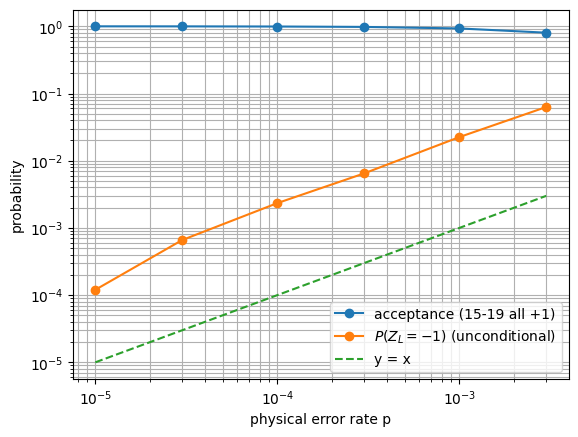

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.xscale("log")
plt.yscale("log")
plt.plot(p_list, acc_rate, marker="o", label="acceptance (15-19 all +1)")
plt.plot(p_list, pZL_minus, marker="o", label=r"$P(Z_L=-1)$ (unconditional)")
plt.plot(p_list, p_list, linestyle="--", label="y = x")
plt.xlabel("physical error rate p")
plt.ylabel("probability")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [24]:
import numpy as np
import qsample as qs

p = np.array([1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3], float)

# 例：设定相对强度（你可以按论文设定修改）
a1 = 1.0   # 1q
a2 = 10.0  # 2q 通常更差
ami = 1.0  # init
amm = 1.0  # meas
aid = 0.5  # idle（若按 T2 推出来也行）

err_model  = qs.noise.E3
err_params = {
    "q1":   a1 * p,
    "q2":   a2 * p,
    "init": ami * p,
    "meas": amm * p,
    "idle": aid * p,
}

sam = qs.DirectSampler(
    protocol=build_tetra_protocol_accept(),     # 你之前跑通的那个
    simulator=qs.StabilizerSimulator,
    err_model=err_model,
    err_params=err_params,
)

cb = AccAndZL()   # 你第一段 callback
sam.run(n_shots=50000, callbacks=[cb])

acc_rate_m, pZL_minus_m = cb.summary()
print("acceptance =", acc_rate_m)
print("P(ZL=-1) unconditional =", pZL_minus_m)

p=('1.00e-05', '1.00e-04', '1.00e-05', '5.00e-06', '1.00e-05'):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('3.00e-05', '3.00e-04', '3.00e-05', '1.50e-05', '3.00e-05'):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('1.00e-04', '1.00e-03', '1.00e-04', '5.00e-05', '1.00e-04'):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('3.00e-04', '3.00e-03', '3.00e-04', '1.50e-04', '3.00e-04'):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('1.00e-03', '1.00e-02', '1.00e-03', '5.00e-04', '1.00e-03'):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('3.00e-03', '3.00e-02', '3.00e-03', '1.50e-03', '3.00e-03'):   0%|          | 0/50000 [00:00<?, ?it/s]

acceptance = [0.99372 0.98288 0.94304 0.83474 0.56932 0.23966]
P(ZL=-1) unconditional = [0.00016 0.00064 0.00218 0.00682 0.02204 0.06488]


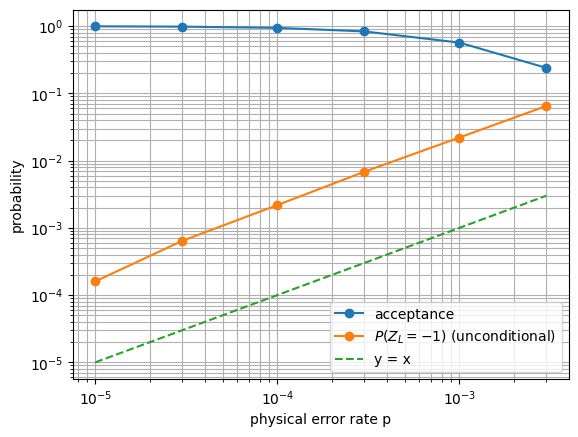

In [28]:
import matplotlib.pyplot as plt
plt.figure()
plt.xscale("log")
plt.yscale("log")
plt.plot(p, acc_rate_m, marker="o", label="acceptance")
plt.plot(p, pZL_minus_m, marker="o", label=r"$P(Z_L=-1)$ (unconditional)")
plt.plot(p, p, linestyle="--", label="y = x")
plt.xlabel("physical error rate p")
plt.ylabel("probability")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [29]:
# import inspect, qsample as qs
# print(qs.SubsetSampler)
# print(inspect.signature(qs.SubsetSampler))
# print(inspect.getsource(qs.SubsetSampler.__init__))


In [30]:
# def is_acc(m): return m == 0
# def is_zl_minus(m): return ((m >> 4) & 1) == 1

# def build_tetra_protocol_for_subset():
#     prep = get_tetra_zero_prep()
#     ver  = get_tetra_flag_verification()

#     prep.noisy = True
#     ver.noisy  = True

#     def is_acc(m):      # 15-19 all +1  <=> msmt == 0
#         return m == 0

#     def is_zl_minus(m): # anc15==1 => Z_L=-1  (bit4)
#         return ((m >> 4) & 1) == 1

#     proto = qs.Protocol(check_functions={"is_acc": is_acc, "is_zl_minus": is_zl_minus})
#     proto.add_nodes_from(["PREP", "VER"], circuits=[prep, ver])

#     proto.add_edge("START", "PREP", check="True")
#     proto.add_edge("PREP",  "VER",  check="True")

#     # ✅ 互斥分流（只能有一条 True）
#     proto.add_edge("VER", "ACC",     check="is_acc(VER[-1])")
#     proto.add_edge("VER", "ZLMINUS", check="(not is_acc(VER[-1])) and is_zl_minus(VER[-1])")
#     proto.add_edge("VER", "OTHER",   check="(not is_acc(VER[-1])) and (not is_zl_minus(VER[-1]))")

#     # 终止：统一到 FAIL（保持文档语义）
#     proto.add_edge("ACC",     "FAIL", check="True")
#     proto.add_edge("ZLMINUS", "FAIL", check="True")
#     proto.add_edge("OTHER",   "FAIL", check="True")

#     return proto


# proto2 = build_tetra_protocol_for_subset()
# proto2.draw(figsize=(12,6))

# sam = qs.DirectSampler(protocol=proto2, simulator=qs.StabilizerSimulator,
#                        err_model=qs.noise.E1_1, err_params={"q":[1e-3]})
# sam.run(20, callbacks=[])  


In [31]:
# import numpy as np
# import matplotlib.pyplot as plt
# import qsample as qs

# proto = build_tetra_protocol_for_subset()
# p_list = np.array([1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3], dtype=float)

# # ===== 计算 L（对你这个线性协议，L=2 很正常）=====
# err_inst = qs.noise.S1()
# L = 0
# for cid, circuit in proto.circuits.items():
#     parts = err_inst.group(circuit)
#     L += 1  # 这里按“电路节点数”也行；你现在协议就是 PREP+VER=2
# print("L =", L)






In [32]:
# import numpy as np
# from qsample.callbacks import Callback

# class AccAndZL_Compat(Callback):
#     def on_sampler_begin(self, sampler):
#         # DirectSampler: sampler.err_params 是 matrix，shape[0]=点数
#         # SubsetSampler: 也有 err_params，但不保证有 i
#         try:
#             n = sampler.err_params.shape[0]
#         except Exception:
#             n = 1
#         self.shots = np.zeros(n, dtype=int)
#         self.acc   = np.zeros(n, dtype=int)
#         self.zl_minus = np.zeros(n, dtype=int)
#         self._ver = None

#     def on_protocol_begin(self, sampler):
#         self._ver = None

#     def on_circuit_end(self, sampler, local_vars):
#         if local_vars.get("pnode") == "VER":
#             self._ver = local_vars.get("msmt")  # int

#     def on_protocol_end(self, sampler):
#         # ✅ DirectSampler 有 i；SubsetSampler 没有 i
#         i = getattr(sampler, "i", 0)

#         self.shots[i] += 1
#         m = self._ver
#         if m is None:
#             return

#         # 接受：15-19 全 +1 <=> msmt==0
#         if m == 0:
#             self.acc[i] += 1

#         # 无条件逻辑Z=-1：anc15 是 bit4（测量顺序(15,16,17,18,19)）
#         anc15 = (m >> 4) & 1
#         if anc15 == 1:
#             self.zl_minus[i] += 1

#     def summary(self):
#         acc_rate = self.acc / np.maximum(self.shots, 1)
#         pZL_minus = self.zl_minus / np.maximum(self.shots, 1)
#         return acc_rate, pZL_minus

# cb = AccAndZL_Compat()
# ss.run(50000, callbacks=[cb])
# acc_s, pzl_s = cb.summary()
# print("p_max =", p_max, "acc =", acc_s, "pZL =", pzl_s)

In [33]:
import qsample as qs
import numpy as np
import matplotlib.pyplot as plt

def is_acc(m):         # 15-19 all +1  <=> msmt==0
    return m == 0

def is_reject(m):
    return not is_acc(m)

def is_zl_minus(m):    # anc15==1, (15,16,17,18,19) -> bit4 is qubit15
    return ((m >> 4) & 1) == 1

def is_not_zl_minus(m):
    return not is_zl_minus(m)


def build_proto_reject_as_fail():
    prep = get_tetra_zero_prep()
    ver  = get_tetra_flag_verification()
    prep.noisy = True
    ver.noisy  = True

    proto = qs.Protocol(check_functions={"is_reject": is_reject})
    proto.add_nodes_from(["PREP", "VER"], circuits=[prep, ver])

    proto.add_edge("START", "PREP", check="True")
    proto.add_edge("PREP",  "VER",  check="True")

    # ✅ reject -> FAIL（只要 msmt != 0）
    proto.add_edge("VER", "FAIL", check="is_reject(VER[-1])")

    # ✅ accept -> 结束：没有边为 True 时，protocol 终止（success event）
    # 所以这里不要写兜底 True 边！

    return proto



def build_proto_zlminus_as_fail():
    prep = get_tetra_zero_prep()
    ver  = get_tetra_flag_verification()
    prep.noisy = True
    ver.noisy  = True

    proto = qs.Protocol(check_functions={"is_zl_minus": is_zl_minus})
    proto.add_nodes_from(["PREP", "VER"], circuits=[prep, ver])

    proto.add_edge("START", "PREP", check="True")
    proto.add_edge("PREP",  "VER",  check="True")

    # ✅ anc15==1 -> FAIL
    proto.add_edge("VER", "FAIL", check="is_zl_minus(VER[-1])")

    # ✅ anc15==0 -> 结束（success）

    return proto


def run_subset(proto, p_list, p_max=1e-2, L=2, n_shots=50000):
    ss = qs.SubsetSampler(
        protocol=proto,
        simulator=qs.StabilizerSimulator,
        p_max={"q": float(p_max)},          # 必须标量
        err_model=qs.noise.S1,
        err_params={"q": np.array(p_list, dtype=float)},
        L=L
    )
    ss.run(n_shots, callbacks=[])          # 不用自定义 callback
    pL_low, std_low, pL_up, std_up = ss.stats()
    return pL_low, std_low, pL_up, std_up


p_list = np.array([1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2], dtype=float)

# A) acceptance：先跑 reject-as-FAIL 得到 P(reject)，再 1 - P(reject)
proto_rej = build_proto_reject_as_fail()
rej_low, rej_std_low, rej_up, rej_std_up = run_subset(proto_rej, p_list, p_max=1e-2, L=2, n_shots=50000)

acc_low = 1 - rej_up      # 注意：reject 的上界 -> acceptance 的下界
acc_up  = 1 - rej_low     # reject 的下界 -> acceptance 的上界

# B) P(ZL=-1)：跑 zlminus-as-FAIL
proto_zl = build_proto_zlminus_as_fail()
zl_low, zl_std_low, zl_up, zl_std_up = run_subset(proto_zl, p_list, p_max=1e-2, L=2, n_shots=50000)



p=('1.00e-02',):   0%|          | 0/50000 [00:00<?, ?it/s]

p=('1.00e-02',):   0%|          | 0/50000 [00:00<?, ?it/s]

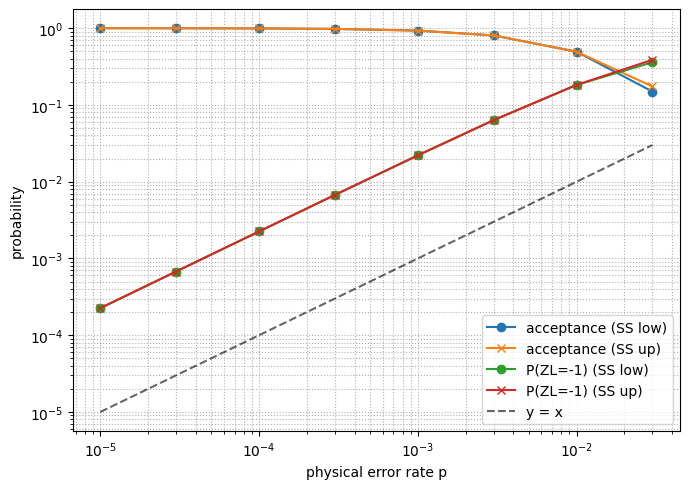

In [34]:
# ===== 画图（loglog）=====
plt.figure(figsize=(7,5))
plt.loglog(p_list, acc_low, marker='o', label="acceptance (SS low)")
plt.fill_between(p_list, acc_low-rej_std_low, acc_low+rej_std_low, alpha=0.2)
plt.loglog(p_list, acc_up, marker='x', label="acceptance (SS up)")
plt.fill_between(p_list, acc_up-rej_std_up, acc_up+rej_std_up, alpha=0.2)

plt.loglog(p_list, zl_low, marker='o', label="P(ZL=-1) (SS low)")
plt.fill_between(p_list, zl_low - zl_std_low, zl_low + zl_std_low, alpha=0.2)
plt.loglog(p_list, zl_up, marker='x', label="P(ZL=-1) (SS up)")
plt.fill_between(p_list, zl_up - zl_std_up, zl_up + zl_std_up, alpha=0.2)

plt.loglog(p_list, p_list, 'k--', alpha=0.6, label="y = x")

plt.xlabel("physical error rate p")
plt.ylabel("probability")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

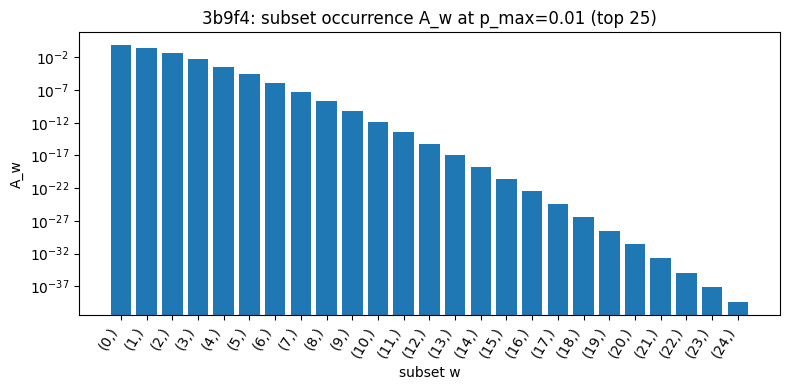

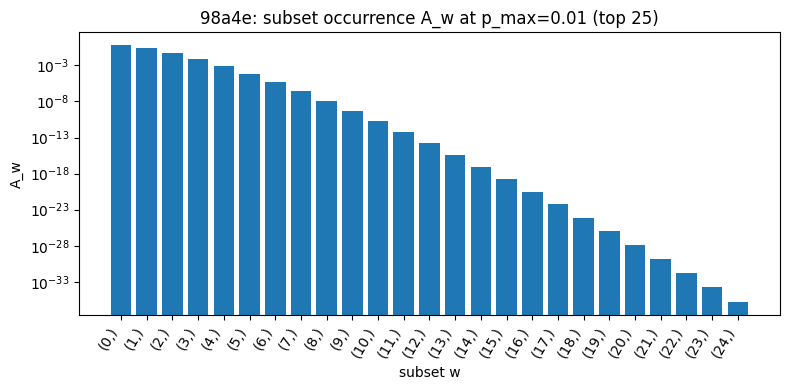

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import qsample as qs

def plot_subset_probs_for_proto(proto, p_max=1e-2, topk=25):
    em = qs.noise.E1_1()  # 注意这里要实例化
    for cid, circuit in proto.circuits.items():
        Aws = qs.math.subset_probs(circuit, em, float(p_max))  # p_max 必须 float

        # 排序并只取最大的 topk 个，图会清楚很多
        items = sorted(Aws.items(), key=lambda kv: float(np.asarray(kv[1]).squeeze()), reverse=True)[:topk]
        xs = [str(k) for k, _ in items]
        ys = [float(np.asarray(v).squeeze()) for _, v in items]

        plt.figure(figsize=(8,4))
        plt.title(f"{cid}: subset occurrence A_w at p_max={p_max:g} (top {topk})")
        plt.bar(range(len(xs)), ys)
        plt.yscale("log")
        plt.xticks(range(len(xs)), xs, rotation=60, ha="right")
        plt.ylabel("A_w")
        plt.xlabel("subset w")
        plt.tight_layout()
        plt.show()

# 用你现在的 protocol（accept 那个就行，因为 circuits 一样）
proto = build_proto_reject_as_fail()
plot_subset_probs_for_proto(proto, p_max=1e-2, topk=25)

In [124]:
p_list = np.array([1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3], float)

for pm in [1e-3, 1e-2]:
    proto_rej = build_proto_reject_as_fail()
    rej_low, rej_std_low, rej_up, rej_std_up = run_subset(proto_rej, p_list, p_max=pm, L=2, n_shots=20000)

    acc_low = 1 - rej_up
    acc_up  = 1 - rej_low

    proto_zl = build_proto_zlminus_as_fail()
    zl_low, zl_std_low, zl_up, zl_std_up = run_subset(proto_zl, p_list, p_max=pm, L=2, n_shots=20000)

    print("p_max =", pm)
    print("  acc interval width at each p:", (acc_up - acc_low))
    print("  zl interval width  at each p:", (zl_up  - zl_low))

p=('1.00e-03',):   0%|          | 0/20000 [00:00<?, ?it/s]

p=('1.00e-03',):   0%|          | 0/20000 [00:00<?, ?it/s]

p_max = 0.001
  acc interval width at each p: [1.97855066e-11 5.34299049e-10 1.97885167e-08 5.34210136e-07
 1.97551420e-05 5.26927281e-04]
  zl interval width  at each p: [1.97854554e-11 5.34298971e-10 1.97885167e-08 5.34210136e-07
 1.97551420e-05 5.26927281e-04]


p=('1.00e-02',):   0%|          | 0/20000 [00:00<?, ?it/s]

p=('1.00e-02',):   0%|          | 0/20000 [00:00<?, ?it/s]

p_max = 0.01
  acc interval width at each p: [-3.55271368e-15 -1.99840144e-15 -5.55111512e-16  1.60871316e-13
  2.15062856e-10  1.38977575e-07]
  zl interval width  at each p: [-3.50620141e-15 -2.04198637e-15  2.48412402e-15  9.05108453e-13
  4.80927406e-10  1.79716218e-07]


In [41]:
import numpy as np
import qsample as qs
print('Hello')
p = np.array([1e-5, 3e-5], float)

# 同 DirectSampler 的比例
a1,a2,ami,amm,aid = 1.0,10.0,1.0,1.0,0.5

err_model = qs.noise.E3
err_params = {
    "q1":   a1*p,
    "q2":   a2*p,
    "init": ami*p,
    "meas": amm*p,
    "idle": aid*p,
}

# p_max 也要按 group 给标量（一般取比 max(p) 大一些；你前面比较后用 1e-2 很稳）
p_max_m = {"q1":1e-3, "q2":1e-3, "init":1e-3, "meas":1e-3, "idle":1e-3}

ss_rej = qs.SubsetSampler(
    protocol=build_proto_reject_as_fail(),   # 你按解法2写的 reject->FAIL 协议
    simulator=qs.StabilizerSimulator,
    p_max=p_max_m,
    err_model=err_model,
    err_params=err_params,
    L=2,
)
print('Running reject-as-fail')
ss_rej.run(10, callbacks=[])

rej_low, rej_std_low, rej_up, rej_std_up = ss_rej.stats()
acc_low = 1 - rej_up
acc_up  = 1 - rej_low

Hello
Running reject-as-fail


p=('1.00e-03', '1.00e-03', '1.00e-03', '1.00e-03', '1.00e-03'):   0%|          | 0/10 [00:00<?, ?it/s]

ValueError: probabilities contain NaN

In [ ]:
ss_zl = qs.SubsetSampler(
    protocol=build_proto_zlminus_as_fail(),  # 你按解法2写的 zlminus->FAIL 协议
    simulator=qs.StabilizerSimulator,
    p_max=p_max_m,
    err_model=err_model,
    err_params=err_params,
    L=2,
)
ss_zl.run(10, callbacks=[])

zl_low, zl_std_low, zl_up, zl_std_up = ss_zl.stats()

In [45]:
import qsample as qs

# -----------------------
# qubit indexing
# -----------------------
T = list(range(15))            # tetra data 0..14
S = list(range(20, 27))        # steane data 20..26

# Eq.(4): control=Steane, target=Tetrahedral
CNOT_ST = {
    (S[0], 10),
    (S[1], 14),
    (S[2], 13),
    (S[3],  0),
    (S[4],  3),
    (S[5],  7),
    (S[6],  6),
}

# -----------------------
# helper: parity of an int bitstring
# (0 -> even -> +1 eigenvalue, 1 -> odd -> -1 eigenvalue)
# -----------------------
def parity(msmt_int: int) -> int:
    return bin(int(msmt_int)).count("1") & 1

# teleport feed-forward conditions
def need_Z_on_T_from_XmeasS(msmt_sx: int) -> bool:
    # measure Steane in X basis => logical-X outcome bit (toy decoder: parity)
    return parity(msmt_sx) == 1

def need_X_on_S_from_ZmeasT(msmt_tz: int) -> bool:
    # measure Tetra in Z basis => logical-Z outcome bit (toy decoder: parity)
    return parity(msmt_tz) == 1

def tetra_accept_from_flags(msmt_flags: int) -> bool:
    # 你的 TVER 只测 anc(15..19)，你已调成 tuple 顺序；全 0 <=> +1...+1
    return int(msmt_flags) == 0


# -----------------------
# Steane encoded state preps (简化版：用 X-stabilizer Latin-rectangle 风格编码 |0_L>)
# 这不是论文 Fig.11 的 flag-FT 版本，但先足够让 protocol 结构/采样跑通
# -----------------------
def steane_zero_L(noisy=True):
    ticks = []
    ticks.append({"init": set(S)})

    # controls for X-stabilizers: choose 3,0,1
    ticks.append({"H": {S[3], S[0], S[1]}})
    ticks.append({"CNOT": {(S[3], S[4]), (S[3], S[5]), (S[3], S[6])}})
    ticks.append({"CNOT": {(S[0], S[2]), (S[0], S[4]), (S[0], S[6])}})
    ticks.append({"CNOT": {(S[1], S[2]), (S[1], S[5]), (S[1], S[6])}})

    return qs.Circuit(ticks, noisy=noisy)

def steane_plus_L(noisy=True):
    c = steane_zero_L(noisy=noisy)
    # logical H is transversal in Steane, so |+_L> = H^{⊗7} |0_L>
    c.ticks.append({"H": set(S)})
    return c

def steane_plusi_L(noisy=True):
    c = steane_plus_L(noisy=noisy)
    # |+i_L> = S |+_L>, S is transversal in Steane
    c.ticks.append({"S": set(S)})
    return c


# -----------------------
# building blocks circuits
# -----------------------
def cnot_steane_to_tetra(noisy=True):
    return qs.Circuit([{"CNOT": CNOT_ST}], noisy=noisy)

def meas_steane_X(noisy=True):
    # X-basis measurement = H then Z-measure
    return qs.Circuit([{"H": set(S)}, {"measure": tuple(S)}], noisy=noisy)

def meas_tetra_Z(noisy=True):
    return qs.Circuit([{"measure": tuple(T)}], noisy=noisy)

def apply_Z_on_tetra(noisy=True):
    # “logical Z” 简化为 Z^{⊗15}（论文里也用它做默认示例）:contentReference[oaicite:4]{index=4}
    return qs.Circuit([{"Z": set(T)}], noisy=noisy)

def apply_X_on_steane(noisy=True):
    # “logical X” 简化为 X^{⊗7}（同上）:contentReference[oaicite:5]{index=5}
    return qs.Circuit([{"X": set(S)}], noisy=noisy)

def noisy_identity_proxy_for_T(noisy=True):
    # 论文 Sec.3 的 proxy：把物理 T 替换为 noisy identity :contentReference[oaicite:6]{index=6}
    # qsample 里 gate 名可能叫 "idle" 或 "I"
    # 如果你这里报 unknown gate，就把 "idle" 改成 "I"
    return qs.Circuit([{"idle": set(T)}], noisy=noisy)

def meas_steane_Y(noisy=True):
    # Y-basis measurement = (S† then H then Z-measure).
    # 若 qsample 没有 Sdg，就用 S^3 = S†
    return qs.Circuit(
        [
            {"S": set(S)}, {"S": set(S)}, {"S": set(S)},
            {"H": set(S)},
            {"measure": tuple(S)}
        ],
        noisy=noisy
    )


# -----------------------
# Protocol: |0>_T prep+verify  ->  teleport up  ->  (T proxy) -> teleport down -> measure Y to define FAIL
# -----------------------
def build_Tgate_proxy_protocol():
    t_prep = get_tetra_zero_prep()
    t_ver  = get_tetra_flag_verification()

    s_in   = steane_plusi_L(noisy=True)     # 论文 proxy 用 |+i>_S :contentReference[oaicite:7]{index=7}
    cn1    = cnot_steane_to_tetra(noisy=True)
    msx    = meas_steane_X(noisy=True)
    zcorr  = apply_Z_on_tetra(noisy=True)
    tidle  = noisy_identity_proxy_for_T(noisy=True)
    s_aux  = steane_plus_L(noisy=True)
    cn2    = cnot_steane_to_tetra(noisy=True)
    mtz    = meas_tetra_Z(noisy=True)
    xcorr  = apply_X_on_steane(noisy=True)
    my     = meas_steane_Y(noisy=True)

    proto = qs.Protocol(check_functions={
        "tetra_ok": tetra_accept_from_flags,
        "needZ": need_Z_on_T_from_XmeasS,
        "needX": need_X_on_S_from_ZmeasT,
        "parity": parity,
    })

    # 这些节点都有 circuit（SubsetSampler 也能正确建 partitions）
    proto.add_nodes_from(
        ["TPREP","TVER","S_IN","CNOT1","MSX","ZCOR","TIDLE","S_AUX","CNOT2","MTZ","XCOR","MY"],
        circuits=[t_prep,t_ver,s_in,cn1,msx,zcorr,tidle,s_aux,cn2,mtz,xcorr,my]
    )

    # --- state prep loop for |0>_T ---
    proto.add_edge("START","TPREP", check="True")
    proto.add_edge("TPREP","TVER", check="True")
    proto.add_edge("TVER","TPREP", check="not tetra_ok(TVER[-1])")
    proto.add_edge("TVER","S_IN",  check="tetra_ok(TVER[-1])")

    # --- teleport up: Steane -> Tetra ---
    proto.add_edge("S_IN","CNOT1", check="True")
    proto.add_edge("CNOT1","MSX",  check="True")

    # if logical-X measurement on S is -1, apply Z^{⊗15} on T (else skip)
    proto.add_edge("MSX","ZCOR",   check="needZ(MSX[-1])")
    proto.add_edge("MSX","TIDLE",  check="not needZ(MSX[-1])")
    proto.add_edge("ZCOR","TIDLE", check="True")

    # --- "T gate" proxy (noisy identity) ---
    proto.add_edge("TIDLE","S_AUX", check="True")

    # --- teleport down: Tetra -> Steane (onto |+>_S aux) ---
    proto.add_edge("S_AUX","CNOT2", check="True")
    proto.add_edge("CNOT2","MTZ",   check="True")

    # if logical-Z measurement on T is -1, apply X^{⊗7} on S (else skip)
    proto.add_edge("MTZ","XCOR",    check="needX(MTZ[-1])")
    proto.add_edge("MTZ","MY",      check="not needX(MTZ[-1])")
    proto.add_edge("XCOR","MY",     check="True")

    # --- define FAIL by final logical-Y check on Steane ---
    # |+i> is +1 eigenstate of logical Y, so FAIL if parity == 1 (odd => -1)
    proto.add_edge("MY","FAIL", check="parity(MY[-1]) == 1")

    return proto

In [43]:
p_list = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
proto = build_Tgate_proxy_protocol()

sam = qs.DirectSampler(
    protocol=proto,
    simulator=qs.StabilizerSimulator,
    err_model=qs.noise.E1_1,
    err_params={"q": p_list},
)

sam.run(n_shots=20000, callbacks=[qs.callbacks.PlotStats()])  # 直接画 p_L

AttributeError: 'Circuit' object has no attribute 'ticks'

In [44]:
proto = build_Tgate_proxy_protocol()
p_list = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]

# L：无故障路径里“会执行的 circuit 节点数”上界（保守一点也行）
L = 12  # 你这个结构大概 10~12，先给 12

ss = qs.SubsetSampler(
    protocol=proto,
    simulator=qs.StabilizerSimulator,
    p_max={"q": 1e-2},                 # 先按你选的 p_max
    err_model=qs.noise.E1_1,
    err_params={"q": p_list},
    L=L,
)

ss.run(2000, callbacks=[qs.callbacks.PlotStats()])

# 如果你想自己拿数：
pL_low, std_low, pL_up, std_up = ss.stats()
print(pL_low, pL_up)

AttributeError: 'Circuit' object has no attribute 'ticks'